Dataset shape: (21799, 28)
Column names: Index(['ecg_id', 'patient_id', 'age', 'sex', 'height', 'weight', 'nurse',
       'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis',
       'infarction_stadium1', 'infarction_stadium2', 'validated_by',
       'second_opinion', 'initial_autogenerated_report', 'validated_by_human',
       'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems',
       'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr'],
      dtype='object')
First few rows:
    ecg_id  patient_id   age  sex  height  weight  nurse  site     device  \
0       1     15709.0  56.0    1     NaN    63.0    2.0   0.0  CS-12   E   
1       2     13243.0  19.0    0     NaN    70.0    2.0   0.0  CS-12   E   
2       3     20372.0  37.0    1     NaN    69.0    2.0   0.0  CS-12   E   
3       4     17014.0  24.0    0     NaN    82.0    2.0   0.0  CS-12   E   
4       5     17448.0  19.0    1     NaN    70.0    2.0   0.0  CS-12   E   

  

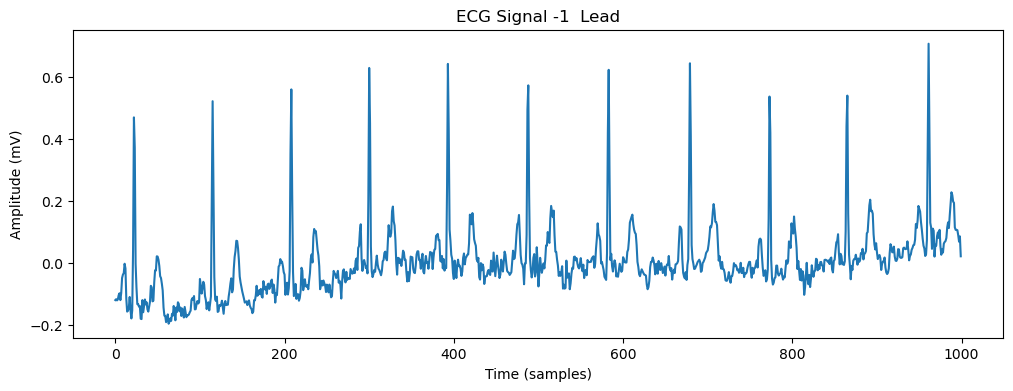

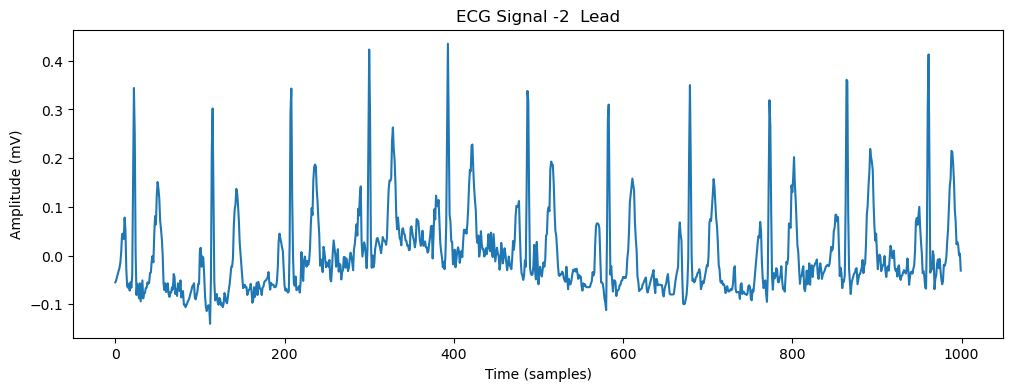

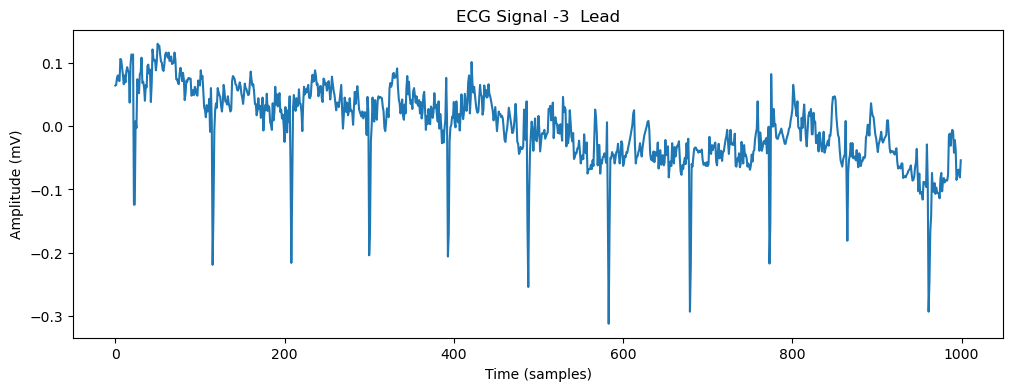

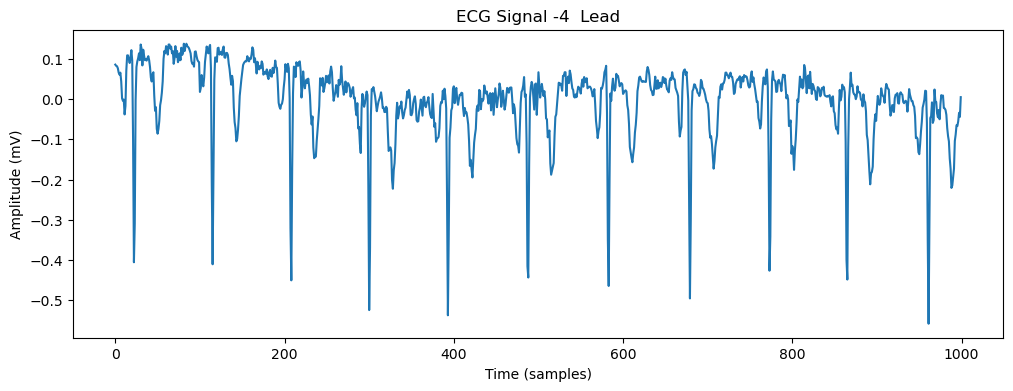

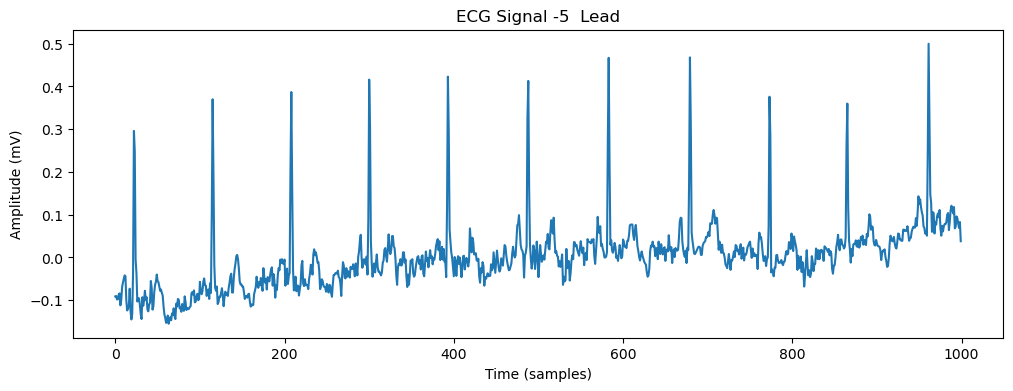

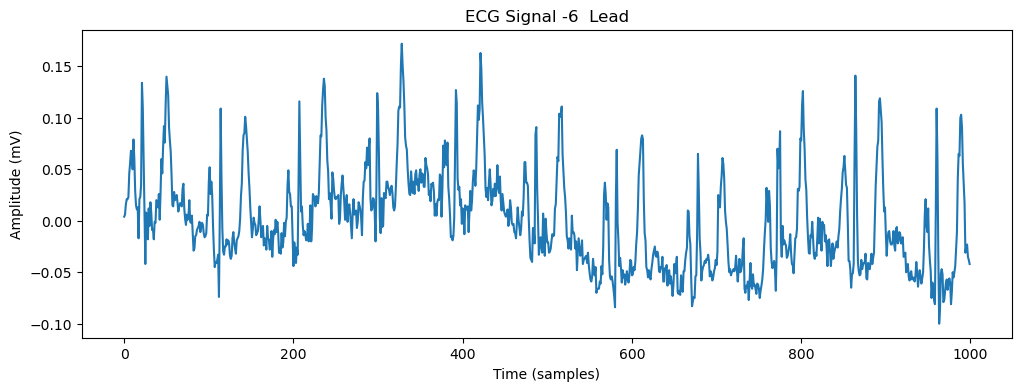

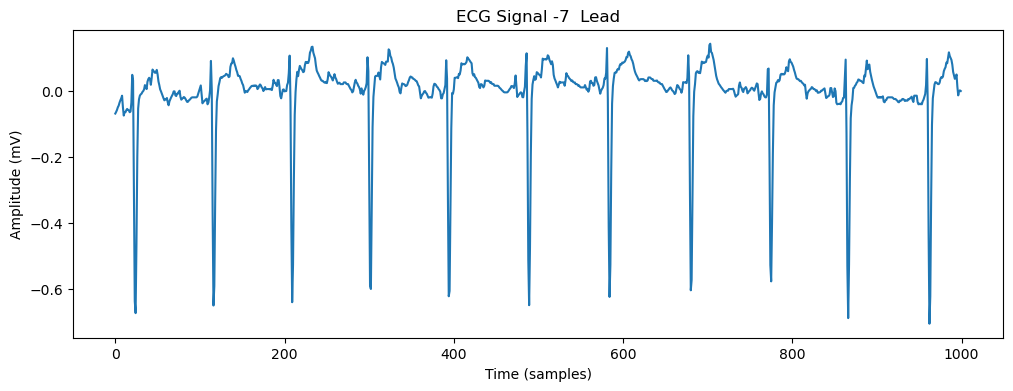

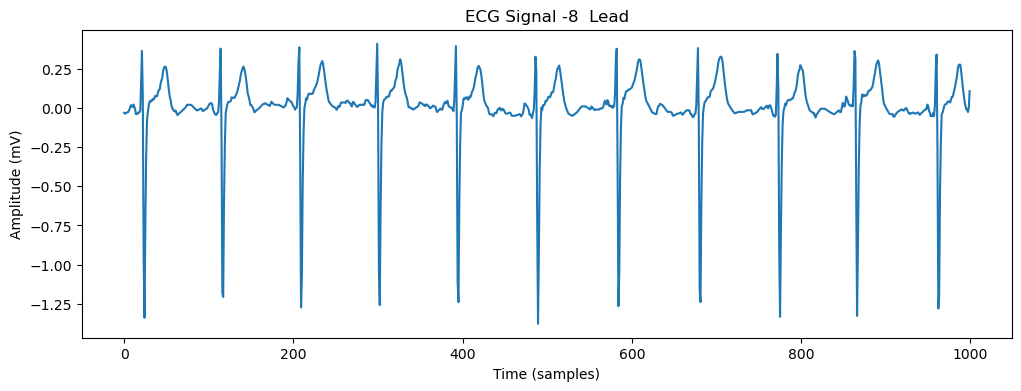

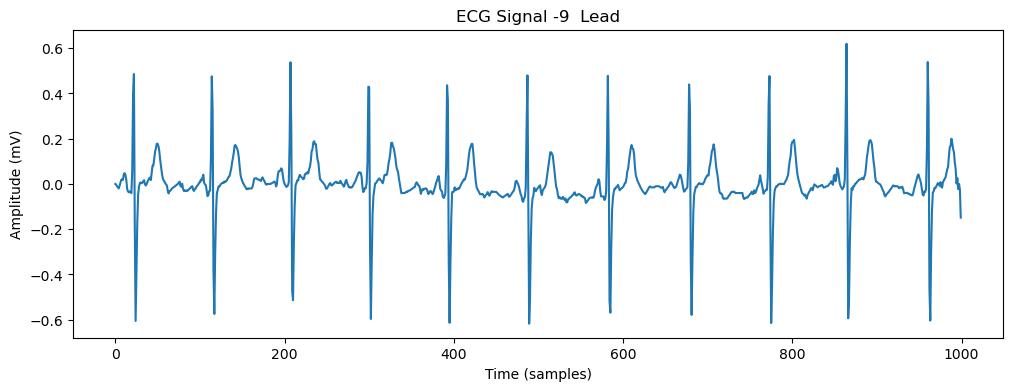

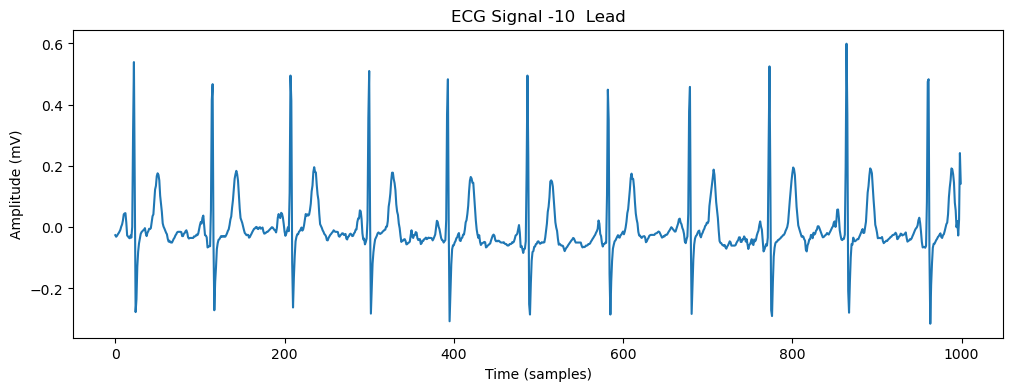

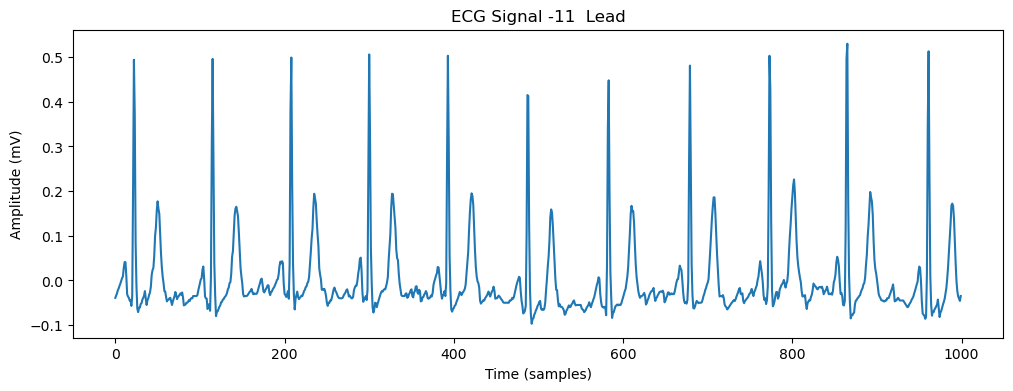

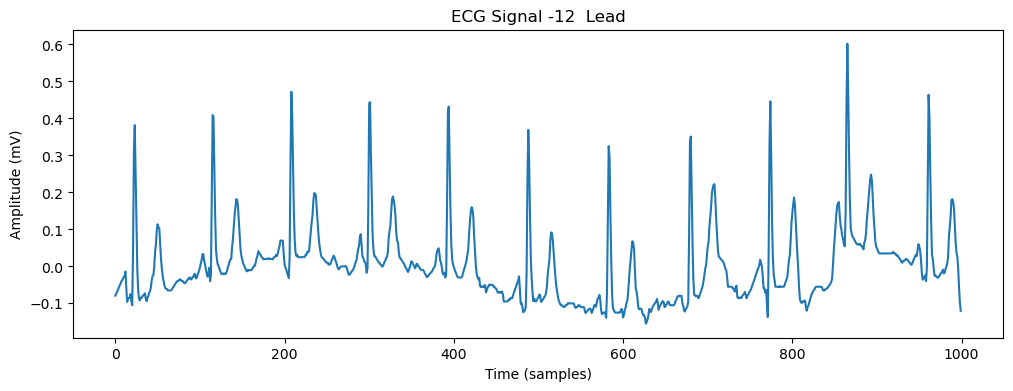

In [6]:
import pandas as pd
import wfdb
import numpy as np
import matplotlib.pyplot as plt

# Load metadata from CSV
ptbxl_path = "C:/Users/Asus/Desktop/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/ptbxl_database.csv"  # Path for this file
data = pd.read_csv(ptbxl_path)
# Display basic info
print("Dataset shape:", data.shape)
print("Column names:", data.columns)
print("First few rows:\n", data.head())

# Load a sample ECG record
def load_ecg_record(record_name, base_path="C:/Users/Asus/Desktop/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/"):
    record_path = base_path + record_name
    signals, fields = wfdb.rdsamp(record_path)
    return signals, fields

# Example: Load first ECG record
sample_record = data.loc[0, "filename_lr"].replace(".dat", "")  # Remove extension
signals, fields = load_ecg_record(sample_record)


print("Sampling frequency:", fields["fs"],"Hz")
print("Leads:", fields["sig_name"])


# Display ECG signal info
print("Signal shape:", signals.shape)

# Plot the first lead of the ECG signal
for i in range(12):
    plt.figure(figsize=(12, 4))
    plt.plot(signals[:, i])
    plt.title(f"ECG Signal -{i+1}  Lead")
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude (mV)")
    plt.show()

In [12]:
import numpy as np
import pandas as pd
import wfdb
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load metadata
ptbxl_path = "C:/Users/Asus/Desktop/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/ptbxl_database.csv"
data = pd.read_csv(ptbxl_path)

# Labeling: Normal (0) vs Abnormal (1)
data["label"] = data["scp_codes"].apply(lambda x: 0 if "NORM" in x else 1)

# Function to extract statistical features
def extract_features(record_name, base_path="C:/Users/Asus/Desktop/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/"):
    record_path = base_path + record_name
    signals, fields = wfdb.rdsamp(record_path)
    
    features = []
    for lead in range(signals.shape[1]):  # Loop over each lead
        features.extend([
            np.mean(signals[:, lead]),  # Mean
            np.std(signals[:, lead]),   # Standard deviation
            np.min(signals[:, lead]),   # Min value
            np.max(signals[:, lead])    # Max value
        ])
    
    return features

# Extract features for all ECG samples
X = []
y = []

for i, row in data.iterrows():
    try:
        features = extract_features(row["filename_lr"].replace(".dat", ""))
        X.append(features)
        y.append(row["label"])
    except:
        continue  # Skip if any issue

X = np.array(X)
y = np.array(y)

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a simple classifier (Random Forest)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7541284403669725
Confusion Matrix:
 [[1385  548]
 [ 524 1903]]
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.72      0.72      1933
           1       0.78      0.78      0.78      2427

    accuracy                           0.75      4360
   macro avg       0.75      0.75      0.75      4360
weighted avg       0.75      0.75      0.75      4360



In [11]:
import pandas as pd
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load metadata
ptbxl_path = "C:/Users/Asus/Desktop/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/ptbxl_database.csv"
data = pd.read_csv(ptbxl_path)

# Display basic info
print("Dataset shape:", data.shape)
print("First few rows:\n", data.head())

# Define function to load ECG signals
def load_ecg_record(record_name, base_path="C:/Users/Asus/Desktop/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/"):
    try:
        record_path = base_path + record_name
        signals, fields = wfdb.rdsamp(record_path)
        return signals
    except Exception as e:
        print(f"Error loading {record_name}: {e}")
        return None

# Feature extraction function
def extract_features(ecg_signal):
    if ecg_signal is None:
        return None  # Skip if loading failed
    mean_vals = np.mean(ecg_signal, axis=0)  # Mean for each lead
    std_vals = np.std(ecg_signal, axis=0)  # Standard deviation for each lead
    rms_vals = np.sqrt(np.mean(ecg_signal**2, axis=0))  # RMS value for each lead
    return np.concatenate([mean_vals, std_vals, rms_vals])  # Combine all features

# Process only first 500 samples (for quick testing)
X_list = []
y_list = []

for i, row in data.head(500).iterrows():  # Change 500 to None to process all
    ecg_signal = load_ecg_record(row["filename_lr"].replace(".dat", ""))
    features = extract_features(ecg_signal)

    if features is not None:
        X_list.append(features)
        y_list.append(1 if "NORM" in row["scp_codes"] else 0)  # Normal = 1, Abnormal = 0

# Convert to NumPy arrays
X = np.array(X_list)
y = np.array(y_list)

# Save extracted features (optional, to avoid reprocessing later)
np.save("X_features.npy", X)
np.save("y_labels.npy", y)

# Load saved features (for future runs)
# X = np.load("X_features.npy")
# y = np.load("y_labels.npy")

print("Feature matrix shape:", X.shape)  # Should be (num_samples, num_features)
print("Label shape:", y.shape)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train a simple Logistic Regression model
clf = LogisticRegression()
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))


Dataset shape: (21799, 28)
First few rows:
    ecg_id  patient_id   age  sex  height  weight  nurse  site     device  \
0       1     15709.0  56.0    1     NaN    63.0    2.0   0.0  CS-12   E   
1       2     13243.0  19.0    0     NaN    70.0    2.0   0.0  CS-12   E   
2       3     20372.0  37.0    1     NaN    69.0    2.0   0.0  CS-12   E   
3       4     17014.0  24.0    0     NaN    82.0    2.0   0.0  CS-12   E   
4       5     17448.0  19.0    1     NaN    70.0    2.0   0.0  CS-12   E   

        recording_date  ... validated_by_human  baseline_drift static_noise  \
0  1984-11-09 09:17:34  ...               True             NaN    , I-V1,     
1  1984-11-14 12:55:37  ...               True             NaN          NaN   
2  1984-11-15 12:49:10  ...               True             NaN          NaN   
3  1984-11-15 13:44:57  ...               True    , II,III,AVF          NaN   
4  1984-11-17 10:43:15  ...               True   , III,AVR,AVF          NaN   

  burst_noise electrodes